# Seasonal Clustering Analysis

This notebook performs comprehensive clustering analysis to identify seasonal patterns in meteorological data across the Indian subcontinent. The analysis pipeline includes:

## Output

The notebook generates three main figures:
- Regional seasonal timing comparison across climate zones
- Spatial bias maps comparing clustering results with observations  
- Dispersion analysis showing correlation between predicted and observed dates

---

In [1]:
# Import required libraries
import xarray as xr
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib as mpl
import geopandas as gpd
from shapely.geometry import mapping

# Import XSeas package
from xseas import SeasonDetect
from xseas.utils import day_of_year_to_date

# Path configuration
import os
from pathlib import Path

# Set global matplotlib style for publication-quality figures
mpl.rcParams.update({
    'font.family': 'Times New Roman',
    'font.size': 11,
    'axes.edgecolor': 'black',
    'axes.linewidth': 1,
    'xtick.direction': 'out',
    'ytick.direction': 'out',
    'xtick.labelsize': 10,
    'ytick.labelsize': 10
})

In [2]:
import yaml

with open('paths.local.yaml', 'r') as file:
    paths = yaml.safe_load(file)

FIGURES_DIR = Path(paths['FIGURES_DIR'])
SUPP_FIGURES_DIR = Path(paths['SUPP_FIGURES_DIR'])
WORKING_FOLDER = Path(paths['WORKING_FOLDER'])

In [3]:
# Ensure figures directory exists
FIGURES_DIR.mkdir(exist_ok=True)

# Define key paths
SHAPEFILES_PATH = WORKING_FOLDER / 'shapefiles'
REFERENCES_PATH = WORKING_FOLDER / 'references'
CONFIG_FILE = 'four_seas_all_vars.yaml'

In [4]:
# Initialize SeasonDetect project with relative paths
project = SeasonDetect(str(WORKING_FOLDER), CONFIG_FILE)

In [5]:
# Load clustering results and reference data
clustering_results = xr.open_dataset(project.clustering_path).breakpoints
clustering_results = clustering_results.rio.set_spatial_dims(x_dim="lon", y_dim="lat", inplace=True)
clustering_results.rio.write_crs("epsg:4326", inplace=True)

# Load reference monsoon dates from IMD
reference_file = REFERENCES_PATH / 'monsoon_dates.nc'
reference_results = xr.open_dataset(reference_file)
reference_results = reference_results.rio.set_spatial_dims(x_dim="lon", y_dim="lat", inplace=True)
reference_results.rio.write_crs("epsg:4326", inplace=True)

print(f"Clustering results shape: {clustering_results.shape}")
print(f"Reference data shape: {reference_results.date.shape}")
print(f"Spatial extent: {clustering_results.lon.min().values:.1f}°E to {clustering_results.lon.max().values:.1f}°E, "
      f"{clustering_results.lat.min().values:.1f}°N to {clustering_results.lat.max().values:.1f}°N")

Clustering results shape: (36, 36, 4)
Reference data shape: (27, 29, 2)
Spatial extent: 65.0°E to 100.0°E, 5.0°N to 40.0°N


In [6]:
# Regional analysis configuration
# Define climate regions for comparative analysis
reg_codes = ['HKK', 'him', 'central_india', 'southwest_india']
reg_names = ['Hindu Kush Karakoram', 'Himalaya', 'Central India', 'Southwest India']

# Color scheme for publication (colorblind-friendly palette)
colors = ['#E69F00', '#009E73', '#D55E00', '#0072B2']
positions = [-0.3, -0.1, 0.1, 0.3]  # Box plot positions for each region

print(f"Analyzing {len(reg_codes)} climate regions:")
for code, name in zip(reg_codes, reg_names):
    print(f"  - {name} ({code})")

Analyzing 4 climate regions:
  - Hindu Kush Karakoram (HKK)
  - Himalaya (him)
  - Central India (central_india)
  - Southwest India (southwest_india)


## Figure 1: Regional Seasonal Timing Analysis

The following figure presents a comparative analysis of seasonal transition dates across four distinct climate regions in the Indian subcontinent. Box plots show the distribution of seasonal onset dates for each of the four seasons (Pre-Monsoon, Monsoon, Post-Monsoon, Winter) identified by the clustering algorithm.

**Key features:**
- **Regional variation**: Different climate zones show distinct seasonal timing patterns
- **IMD reference ranges**: Red shaded areas and annotations indicate the official India Meteorological Department onset and withdrawal periods
- **Seasonal progression**: Clear temporal sequence from Pre-Monsoon through Winter seasons
- **Geographic influence**: Mountain regions (HKK, Himalaya) vs. plains (Central/Southwest India) show different patterns

This analysis validates the clustering methodology by comparing automated seasonal detection with established meteorological knowledge and provides insights into regional climate variations across the Indian subcontinent.

In [7]:
import numpy as np
import matplotlib.pyplot as plt

def fill_annular_sector(ax, start, end, r_inner, r_outer,
                        *, degrees=True, n=200, pad=0.0, **kwargs):
    """
    Riempie un settore anulare [start,end] con raggi [r_inner,r_outer] su assi polari.
    
    Parametri
    ---------
    ax : matplotlib.axes._axes.Axes (projection='polar')
    start, end : float
        Angoli di inizio/fine del settore. In gradi se degrees=True, altrimenti radianti.
    r_inner, r_outer : float
        Raggi interno ed esterno del settore.
    degrees : bool
        Se True, 'start' ed 'end' sono in gradi.
    n : int
        Numero di punti per campionare l'arco.
    pad : float
        Padding angolare (stessa unità di 'start'/'end'): positivo “stringe” l’arco
        su entrambi gli estremi. Utile per simulare il tuo ±0.01 rad.
    **kwargs : dict
        Passato a ax.fill (es. color='crimson', alpha=0.2, zorder=0.3).
    """
    if degrees:
        start = np.deg2rad(start)
        end   = np.deg2rad(end)
        pad   = np.deg2rad(pad)

    # Normalizza in [0, 2π)
    twopi = 2*np.pi
    start = start % twopi
    end   = end   % twopi

    # Applica padding (stringe l'intervallo)
    start += pad
    end   -= pad

    # “Srotola” se attraversa 0
    if end <= start:
        end += twopi

    span = end - start
    # Se praticamente l'intero cerchio, campiona 0..2π
    if span >= twopi - 1e-9:
        theta = np.linspace(0, twopi, n, endpoint=True)
    else:
        theta = np.linspace(start, end, n, endpoint=True)

    # Costruisci poligono in coordinate polari: arco esterno + arco interno inverso
    theta_rev = theta[::-1]
    r_outer_arr = np.full_like(theta, r_outer)
    r_inner_arr = np.full_like(theta, r_inner)

    thetas = np.concatenate([theta, theta_rev])
    rs     = np.concatenate([r_outer_arr, r_inner_arr])

    return ax.fill(thetas, rs, **kwargs)

# Esempio d'uso (equivalente al tuo, ma generalizzato):
# fig, ax = plt.subplots(subplot_kw={'projection': 'polar'})
# fill_annular_sector(ax, start_d, end_d, inner_r + 0.2, outer_r - 0.5,
#                     degrees=True, pad=np.rad2deg(0.01), color='crimson', alpha=0.2, zorder=0.3)
# plt.show()

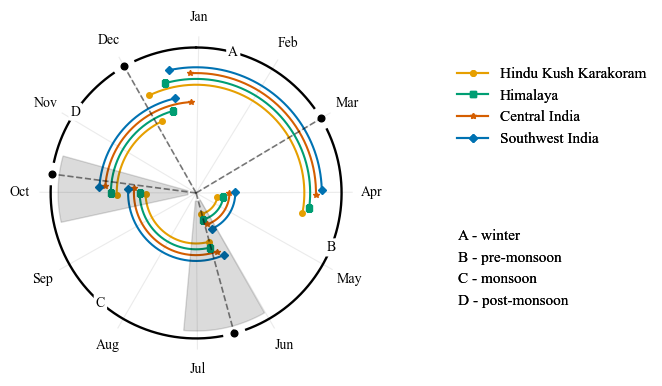

In [8]:
import numpy as np
import matplotlib.pyplot as plt
import geopandas as gpd
from shapely.geometry import mapping
from matplotlib.patches import Wedge
from matplotlib.lines import Line2D

# fill_annular_sector è già definita nel tuo ambiente

season_labels = ['pre-monsoon', 'Monsoon', 'Post-Monsoon', 'Winter']
region_colors = ['#E69F00', '#009E73', '#D55E00', '#0072B2']  # region palette
region_codes_local = reg_codes
region_markers = ['o', 's', '*', 'D']

FILL_FULL_MONSOON_SLICE = True
MONSOON_FILL_ALPHA = 0.1
MONSOON_EDGE_LW = 1

# === Precompute median start/end for each region and season ===
all_stats = []
n_seas = len(season_labels)
for reg_code in region_codes_local:
    region = gpd.read_file(SHAPEFILES_PATH / f'{reg_code}.gpkg')
    reg_data = clustering_results.rio.clip(region.geometry.apply(mapping))
    seas_stats = []
    for s in range(n_seas):
        start_vals = reg_data.isel(cluster=s).values.flatten()
        start_vals = start_vals[~np.isnan(start_vals)]
        end_idx = (s + 1) % n_seas
        end_vals = reg_data.isel(cluster=end_idx).values.flatten()
        end_vals = end_vals[~np.isnan(end_vals)]
        if start_vals.size == 0 or end_vals.size == 0:
            seas_stats.append({'median_start': np.nan, 'median_end': np.nan})
            continue
        ms = float(np.median(start_vals))
        me_raw = float(np.median(end_vals))
        me = me_raw + 365.0 if me_raw < ms else me_raw
        seas_stats.append({'median_start': ms, 'median_end': me})
    all_stats.append(seas_stats)

# === IMD reference ===
imd_onset_vals = reference_results.isel(cluster=0).date.values.flatten()
imd_with_vals  = reference_results.isel(cluster=1).date.values.flatten()
imd_onset_vals = imd_onset_vals[~np.isnan(imd_onset_vals)]
imd_with_vals  = imd_with_vals[~np.isnan(imd_with_vals)]
if imd_onset_vals.size and imd_with_vals.size:
    imd_start_med = float(np.median(imd_onset_vals))
    imd_end_raw   = float(np.median(imd_with_vals))
    imd_end_med   = imd_end_raw + 365.0 if imd_end_raw < imd_start_med else imd_end_raw
else:
    imd_start_med = imd_end_med = np.nan

# === Figure ===
fig = plt.figure(figsize=(4.5, 4.5))
ax = plt.subplot(111, projection='polar')
fig.subplots_adjust(right=0.72)
ax.set_theta_direction(-1)
ax.set_theta_offset(np.pi / 2)

season_band_height = 0.55
sub_spacing = 0.015
sub_band_height = (season_band_height - (len(region_codes_local)-1)*sub_spacing) / len(region_codes_local)
base_r0 = 0.4
convert = lambda d: (d / 365.0) * 360.0
max_r_plot = base_r0 + len(season_labels)*(season_band_height + 0.15) + 0.25

# === Archi mediani per regione ===
for seas_idx, seas_label in enumerate(season_labels):
    season_r0 = base_r0 + seas_idx * (season_band_height + 0.15)
    for r_idx, (reg_name, reg_stats, reg_col, reg_marker) in enumerate(zip(reg_names, all_stats, region_colors, region_markers)):
        stats = reg_stats[seas_idx]
        ms = stats['median_start']; me = stats['median_end']
        if np.isnan(ms) or np.isnan(me): continue
        r0 = season_r0 + r_idx * (sub_band_height + sub_spacing)
        r1 = r0 + sub_band_height
        def plot_arc(s_d, e_d, color):
            segs = [(s_d, 365.0), (0.0, e_d % 365.0)] if e_d <= s_d else [(s_d, e_d)]
            for a0, a1 in segs:
                th1 = convert(a0); th2 = convert(a1)
                ax.plot(np.linspace(np.deg2rad(th1), np.deg2rad(th2), 140),
                        np.full(140, r1), color=color, lw=1.5, zorder=2)
        plot_arc(ms, me, reg_col)
        ax.plot([np.deg2rad(convert(ms))], [r0 + sub_band_height], marker=reg_marker,
                color=reg_col, markersize=4, linestyle='None', zorder=3)
        ax.plot([np.deg2rad(convert(me % 365.0))], [r0 + sub_band_height], marker=reg_marker,
                color=reg_col, markersize=4, linestyle='None', zorder=3)

# === Outer reference ring + variabilità IMD (due settori) + A-bis ===
dec1 = 335.0
mar1 = 60.0
apr1 = 91.0  # 1 April
ms = imd_start_med % 365.0
me = imd_end_med   % 365.0
GAP_DAYS = 5

if not np.isnan(ms) and not np.isnan(me):
    r_ref  = max_r_plot + 0.08
    lw_ref = 1.7
    npts   = 220

    # ---- IMD variability bands via fill_annular_sector ----
    if imd_onset_vals.size:
        on_min = float(np.nanmin(imd_onset_vals)) % 365.0
        on_max = float(np.nanmax(imd_onset_vals)) % 365.0
        # banda onset (più interna)
        fill_annular_sector(
            ax, convert(on_min), convert(on_max),
            r_inner=0.2, r_outer=r_ref - 0.18,
            degrees=True, n=300, pad=0.6,
            color='k', alpha=0.14, zorder=4.6
        )
    if imd_with_vals.size:
        wd_min = float(np.nanmin(imd_with_vals)) % 365.0
        wd_max = float(np.nanmax(imd_with_vals)) % 365.0
        # banda withdrawal (poco sotto al cerchio di riferimento)
        fill_annular_sector(
            ax, convert(wd_min), convert(wd_max),
            r_inner=0.2, r_outer=r_ref - 0.18,
            degrees=True, n=300, pad=0.6,
            color='k', alpha=0.14, zorder=4.6
        )

    # ---- helpers per archi reference ----
    def plot_ref_arc(a0, a1, r=r_ref, lw=lw_ref, ls='-', color='k', z=5):
        a0 %= 365.0; a1 %= 365.0
        spans = [(a0, a1)] if a1 > a0 else [(a0, 365.0), (0.0, a1)]
        for w0, w1 in spans:
            th0 = np.deg2rad(convert(w0)); th1 = np.deg2rad(convert(w1))
            thetas = np.linspace(th0, th1, npts)
            ax.plot(thetas, np.full_like(thetas, r), color=color, lw=lw, ls=ls, zorder=z)

    # Segmenti stagionali base (con gap)
    segments = [
        (mar1 + GAP_DAYS, ms - GAP_DAYS),           # B pre-monsoon
        (ms + GAP_DAYS,  me - GAP_DAYS),            # C monsoon
        (me + GAP_DAYS,  dec1 - GAP_DAYS),          # D post-monsoon
        (dec1 + GAP_DAYS, mar1 + 365.0 - GAP_DAYS)  # A winter
    ]
    seg_letters = ['B', 'C', 'D', 'A']
    for (a0, a1) in segments:
        plot_ref_arc(a0, a1)

    # Pallini + linee radiali
    key_points = [mar1, ms, me, dec1]
    for d in key_points:
        th = np.deg2rad(convert(d))
        ax.plot(th, r_ref, 'o', color='k', markersize=4.8, zorder=7)
        ax.plot([th, th], [r_ref - 0.05, r_ref + 0.05], color='k', lw=1.4, ls='--', zorder=6)
        ax.plot([th, th], [0, r_ref], color='k', lw=1.2, ls='--', alpha=0.5, zorder=4)

    # Lettere al centro dei segmenti
    def seg_mid_doy(a0, a1):
        a1c = a1 if a1 >= a0 else a1 + 365.0
        return (a0 + (a1c - a0)/2.0) % 365.0
    for (a0, a1), letter in zip(segments, seg_letters):
        mid_doy = seg_mid_doy(a0, a1)
        th_mid = np.deg2rad(convert(mid_doy))
        ax.text(th_mid, r_ref, letter, ha='center', va='center',
                fontsize=10, zorder=8,
                bbox=dict(facecolor='white', edgecolor='none', boxstyle='round,pad=0.15'))

    # === A-bis: Dec 1 → Apr 1, sopra il winter, collegato con ":" ===
    # r_ref2 = r_ref + 0.22
    # plot_ref_arc(dec1, apr1, r=r_ref2, z=7)
    # for d in [dec1, apr1]:
    #     th = np.deg2rad(convert(d))
    #     ax.plot([th, th], [r_ref, r_ref2], color='k', lw=1.2, ls=':', zorder=7.5)
    # mid_ab = seg_mid_doy(dec1, apr1)
    # th_mid_ab = np.deg2rad(convert(mid_ab))
    # ax.text(th_mid_ab, r_ref2, 'A.bis', ha='center', va='center',
    #         fontsize=9, zorder=9,
    #         bbox=dict(facecolor='white', edgecolor='none', boxstyle='round,pad=0.15'))

# === Assi ===
month_days = [1, 32, 60, 91, 121, 152, 182, 213, 244, 274, 305, 335]
month_lab = ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']
ax.set_xticks([np.deg2rad(convert(d)) for d in month_days])
ax.set_xticklabels(month_lab, fontsize=10)
ax.set_yticks([])
ax.grid(alpha=0.25)
ax.spines['polar'].set_visible(False)
ax.set_ylim(0, 3.8)

# --- legende ---
fig.set_size_inches(6.0, 5.4)
fig.subplots_adjust(right=0.75, bottom=0.30)

legend_elements = []
for reg_name, reg_col, reg_marker in zip(reg_names, region_colors, region_markers):
    handle = Line2D([0,1],[0,0], color=reg_col, marker=reg_marker, markersize=4,
                    lw=1.5, markerfacecolor=reg_col, markeredgecolor=None, label=reg_name)
    legend_elements.append(handle)

leg1 = fig.legend(handles=legend_elements,
                  loc='center left', bbox_to_anchor=(0.85, 0.75),
                  ncol=1, frameon=False, fontsize=11)
fig.add_artist(leg1)

common_handles = [
    Line2D([], [], color='none', label='A - winter'),
    Line2D([], [], color='none', label='B - pre-monsoon'),
    Line2D([], [], color='none', label='C - monsoon'),
    Line2D([], [], color='none', label='D - post-monsoon'),
]
leg2 = fig.legend(handles=common_handles,
                  loc='center left', bbox_to_anchor=(0.78, 0.45),
                  ncol=1, frameon=False, fontsize=11)
fig.add_artist(leg2)

# === Salvataggio ===
tris_path = FIGURES_DIR / 'clustering_results_polar_coverage_all_regions.png'
fig.savefig(tris_path, dpi=300, bbox_inches='tight', transparent=True)
plt.show()

## Figure 2: Spatial Bias Analysis

The next analysis examines the spatial distribution of bias between clustering-derived seasonal dates and observational references from the India Meteorological Department. This comparison provides crucial validation of the clustering methodology's accuracy across different geographic regions.

**Analysis components:**
- **Onset bias**: Difference between clustering-detected monsoon onset and IMD reference dates
- **Withdrawal bias**: Difference between clustering-detected monsoon withdrawal and IMD reference dates
- **Spatial patterns**: Geographic distribution of bias reveals systematic regional differences
- **Performance assessment**: Quantifies where the clustering method performs well vs. where improvements are needed

**Interpretation:**
- Positive values (red): Clustering predicts later dates than observations
- Negative values (blue): Clustering predicts earlier dates than observations
- Near-zero values (white): Good agreement between clustering and observations

This spatial analysis helps identify geographic regions where the clustering algorithm requires calibration and informs future methodological improvements.

In [9]:
# Prepare data for bias analysis
# Load boundary shapefiles
india_bnd = gpd.read_file(SHAPEFILES_PATH / 'INDIA.gpkg')
boundary = gpd.read_file(SHAPEFILES_PATH / 'boundary.gpkg')
# Clip data to India boundar
india_reference = reference_results.rio.clip(india_bnd.geometry.apply(mapping))
india_cluster = clustering_results.rio.clip(india_bnd.geometry.apply(mapping))

# Calculate bias for onset and withdrawal
# Onset: Compare monsoon season (cluster=1) with first reference date (cluster=0)
onset_bias = india_cluster.isel(cluster=1) - india_reference.isel(cluster=0).date

# Withdrawal: Compare post-monsoon season (cluster=2) with second reference date (cluster=1) 
withdrawal_bias = india_cluster.isel(cluster=2) - india_reference.isel(cluster=1).date

print(f"Onset bias range: {onset_bias.min().values:.1f} to {onset_bias.max().values:.1f} days")
print(f"Withdrawal bias range: {withdrawal_bias.min().values:.1f} to {withdrawal_bias.max().values:.1f} days")

Onset bias range: -33.4 to 40.0 days
Withdrawal bias range: -51.3 to 20.1 days


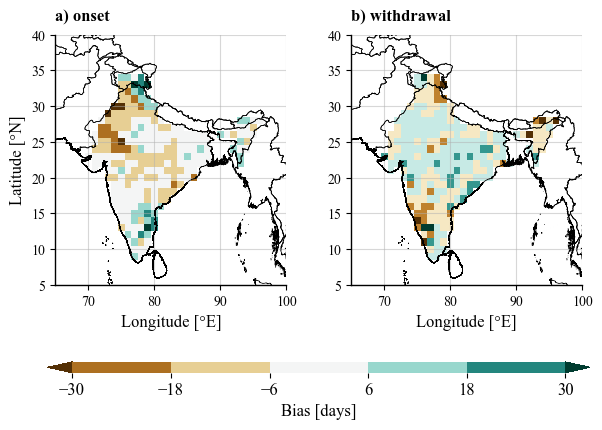

In [10]:
# Create Figure 2: Spatial bias maps
fig, ax = plt.subplots(1, 2, figsize=(7, 5))

# Plot bias maps
onset_bias.plot(vmin=-30, vmax=30, cmap='BrBG', ax=ax[0], add_colorbar=False, levels=6)
withdrawal_bias.plot(vmin=-30, vmax=30, cmap='BrBG', ax=ax[1], add_colorbar=False, levels=6)

# Add country boundaries
boundary.boundary.plot(ax=ax[0], color='k', lw=0.5)
boundary.boundary.plot(ax=ax[1], color='k', lw=0.5)

# Configure both subplots
for a in ax:
    a.set_xlim(65, 100)
    a.set_ylim(5, 40)
    a.set_title('')
    a.set_xlabel('Longitude [°E]', fontsize=12)
    a.set_ylabel('', fontsize=12)
    a.grid(alpha=0.5)
    a.spines['top'].set_visible(False)
    a.spines['right'].set_visible(False)

# Specific labels
ax[0].set_ylabel('Latitude [°N]', fontsize=12)
ax[0].text(0., 1.1, 'a) onset', transform=ax[0].transAxes, fontsize=12, fontweight='bold', va='top', ha='left')
ax[1].text(0., 1.1, 'b) withdrawal', transform=ax[1].transAxes, fontsize=12, fontweight='bold', va='top', ha='left')

# Add shared colorbar
cbar = fig.colorbar(ax[0].collections[0], ax=ax, orientation='horizontal', pad=0.2, aspect=50, extend='both')
cbar.ax.tick_params(labelsize=12)
cbar.ax.set_xlabel('Bias [days]', fontsize=12)
cbar.outline.set_visible(False)

# Save figure
fig.savefig(FIGURES_DIR / 'clustering_bias.png', dpi=300, bbox_inches='tight', transparent=True)
plt.show()

## Figure 3: Correlation and Dispersion Analysis

The final analysis presents scatter plots comparing clustering-derived seasonal dates with observational references on a pixel-by-pixel basis. This provides a quantitative assessment of the clustering methodology's performance across the entire spatial domain.

**Statistical metrics:**
- **Correlation coefficient**: Measures linear relationship strength between predicted and observed dates
- **Slope**: Indicates systematic bias in the relationship (perfect agreement = slope of 1.0)
- **Scatter pattern**: Reveals variability and outliers in the clustering performance
- **Perfect fit line**: Black dashed line shows ideal 1:1 relationship

**Performance indicators:**
- Points close to the perfect fit line indicate good agreement
- Tight scatter around the fit line suggests consistent performance
- Slope values near 1.0 indicate minimal systematic bias
- High correlation coefficients validate the clustering approach

This analysis provides the final validation step, demonstrating the quantitative accuracy of the clustering methodology for automated seasonal detection compared to established meteorological observations.

Onset correlation: 0.351
Withdrawal correlation: 0.526


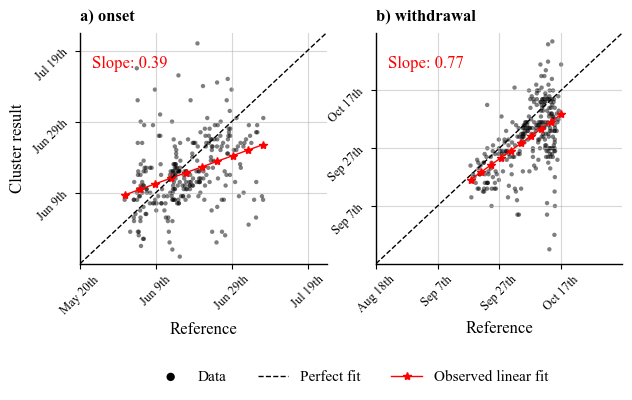

In [11]:
# Create Figure 3: Correlation and dispersion analysis
fig, ax = plt.subplots(1, 2, figsize=(7, 3))

# Analyze both onset (j=0) and withdrawal (j=1)
for j in range(2):
    # Prepare data for correlation analysis
    cluster_data = india_cluster.isel(cluster=j + 1).rename('cluster_result').to_dataframe()
    reference_data = india_reference.isel(cluster=j).date.rename('reference').to_dataframe()
    
    # Merge datasets and remove NaN values
    merged_data = cluster_data.merge(reference_data, on=['lon', 'lat'], suffixes=('_cluster', '_reference'))
    merged_data = merged_data.drop(columns=['spatial_ref_cluster', 'cluster', 'spatial_ref_reference']).dropna()
    
    # Create scatter plot
    merged_data.plot.scatter(x='reference', y='cluster_result', ax=ax[j], alpha=0.5, s=10, c='k', edgecolors='none')
    
    # Calculate and plot linear fit
    coefficients = np.polyfit(merged_data['reference'], merged_data['cluster_result'], 1)
    polynomial = np.poly1d(coefficients)
    x_range = np.linspace(merged_data['reference'].min(), merged_data['reference'].max(), 10)
    ax[j].plot(x_range, polynomial(x_range), 'r-*', lw=1)
    
    # Display slope and calculate correlation
    slope = coefficients[0]
    ax[j].text(0.05, 0.9, f'Slope: {slope:.2f}', transform=ax[j].transAxes, 
               fontsize=12, verticalalignment='top', color='r')
    
    correlation = np.corrcoef(merged_data['reference'], merged_data['cluster_result'])[0, 1]
    print(f'{"Onset" if j == 0 else "Withdrawal"} correlation: {correlation:.3f}')

# Configure first subplot (Onset)
ax[0].set_xlabel('Reference', fontsize=12)
ax[0].set_ylabel('Cluster result', fontsize=12)
ax[0].set_xlim(140, 205)
ax[0].set_ylim(140, 205)
ax[0].plot([140, 205], [140, 205], 'k--', lw=1)
ax[0].set_xticks([140, 160, 180, 200], 
                 labels=[day_of_year_to_date(x) for x in [140, 160, 180, 200]], rotation=45, fontsize=9)
ax[0].set_yticks([160, 180, 200], 
                 labels=[day_of_year_to_date(x) for x in [160, 180, 200]], rotation=45, fontsize=9)

# Configure second subplot (Withdrawal)
ax[1].set_xlabel('Reference', fontsize=12)
ax[1].set_ylabel('', fontsize=12)
ax[1].set_xlim(230, 310)
ax[1].set_ylim(230, 310)
ax[1].plot([230, 310], [230, 310], 'k--', lw=1)
ax[1].set_xticks([230, 250, 270, 290], 
                 labels=[day_of_year_to_date(x) for x in [230, 250, 270, 290]], rotation=45, fontsize=9)
ax[1].set_yticks([250, 270, 290], 
                 labels=[day_of_year_to_date(x) for x in [250, 270, 290]], rotation=45, fontsize=9)

# Style both subplots
for a in ax:
    a.spines['top'].set_visible(False)
    a.spines['right'].set_visible(False)
    a.grid(alpha=0.5)

# Add subplot labels
ax[0].text(0., 1.1, 'a) onset', transform=ax[0].transAxes, fontsize=12, fontweight='bold', va='top', ha='left')
ax[1].text(0., 1.1, 'b) withdrawal', transform=ax[1].transAxes, fontsize=12, fontweight='bold', va='top', ha='left')

# Create legend
ax[0].scatter([], [], c='k', edgecolors='none', label='Data')
ax[0].plot([], [], 'k--', lw=1, label='Perfect fit')
ax[0].plot([], [], 'r-*', lw=1, label='Observed linear fit')
ax[0].legend(loc='upper left', bbox_to_anchor=(0.25, -0.4), fontsize=11, title_fontsize='13', frameon=False, ncol=3)

# Save figure
fig.savefig(FIGURES_DIR / 'clustering_dispersion.png', dpi=300, bbox_inches='tight', transparent=True)
plt.show()